# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2072s 12us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

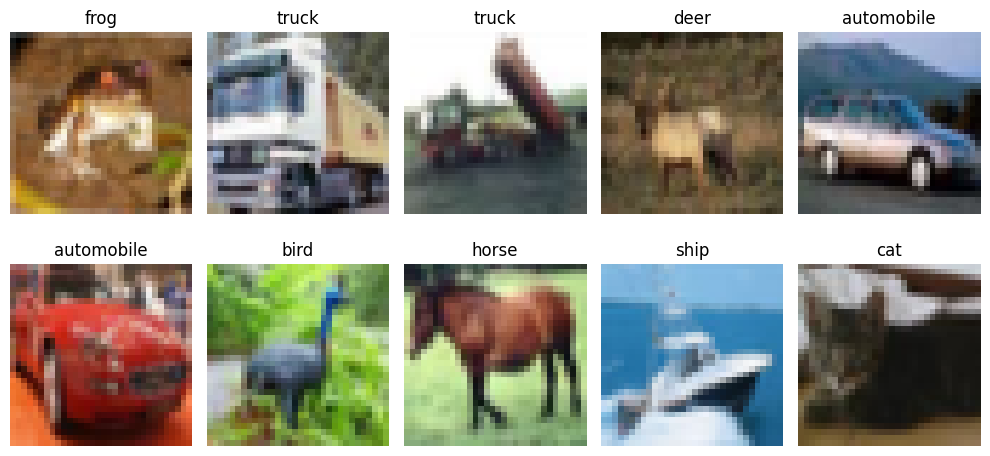

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [ ]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

In [ ]:
early_stop=tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [ ]:
ann_model=models.Sequential([

    layers.Dense(
        1024,
        activation='relu',
        input_shape=(3072,)
    ),

    layers.Dropout(0.4),


    layers.Dense(
        512,
        activation='relu'
    ),

    layers.Dropout(0.3),


    layers.Dense(
        256,
        activation='relu'
    ),


    layers.Dense(
        10,
        activation='softmax'
    )

])


ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


ann_history=ann_model.fit(
    x_train_flat,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)


ann_loss,ann_acc=ann_model.evaluate(
    x_test_flat,
    y_test
)


print("ANN Accuracy:",ann_acc)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 53s 73ms/step - accuracy: 0.2370 - loss: 2.0540 - val_accuracy: 0.3296 - val_loss: 1.8973
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 51s 73ms/step - accuracy: 0.2857 - loss: 1.9315 - val_accuracy: 0.3184 - val_loss: 1.8975
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 77s 66ms/step - accuracy: 0.3016 - loss: 1.8929 - val_accuracy: 0.3572 - val_loss: 1.8361
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 51s 72ms/step - accuracy: 0.3136 - loss: 1.8623 - val_accuracy: 0.3418 - val_loss: 1.8610
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 72ms/step - accuracy: 0.3223 - loss: 1.8505 - val_accuracy: 0.3732 - val_loss: 1.7843
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 73ms/step - accuracy: 0.3278 - loss: 1.8372 - val_accuracy: 0.3730 - val_loss: 1.7983
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 51s 73ms/step - accuracy: 0.3286 - loss: 1.8243 - val_accuracy: 0.3540 - val_loss: 1.8209
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 67ms/step - accuracy: 0.3350 - loss: 1.8122 - 

In [ ]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.3728 - loss: 1.7708
ANN Test Accuracy: 0.37279999256134033


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [ ]:
cnn_model = models.Sequential([


    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(32,32,3)
    ),


    layers.BatchNormalization(),

    layers.MaxPooling2D((2,2)),


    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),


    layers.BatchNormalization(),

    layers.MaxPooling2D((2,2)),


    layers.Conv2D(
        128,
        (3,3),
        activation='relu'
    ),


    layers.Flatten(),


    layers.Dense(
        128,
        activation='relu'
    ),


    layers.Dropout(0.4),


    layers.Dense(
        10,
        activation='softmax'
    )

])


cnn_model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']

)


cnn_history = cnn_model.fit(

    x_train_norm,

    y_train,

    epochs=20,

    validation_split=0.1,

    batch_size=64,

    callbacks=[early_stop]

)


cnn_test_loss, cnn_test_acc = cnn_model.evaluate(

    x_test_norm,

    y_test

)


print("CNN Test Accuracy:", cnn_test_acc)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 100s 136ms/step - accuracy: 0.4668 - loss: 1.4937 - val_accuracy: 0.5388 - val_loss: 1.2491
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 134ms/step - accuracy: 0.6056 - loss: 1.1234 - val_accuracy: 0.5462 - val_loss: 1.3198
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 92s 131ms/step - accuracy: 0.6704 - loss: 0.9569 - val_accuracy: 0.6122 - val_loss: 1.0961
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 94s 133ms/step - accuracy: 0.7125 - loss: 0.8355 - val_accuracy: 0.6240 - val_loss: 1.1833
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 93s 132ms/step - accuracy: 0.7437 - loss: 0.7325 - val_accuracy: 0.5638 - val_loss: 1.3654
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 93s 133ms/step - accuracy: 0.7722 - loss: 0.6504 - val_accuracy: 0.7252 - val_loss: 0.8167
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 95s 135ms/step - accuracy: 0.7929 - loss: 0.5883 - val_accuracy: 0.6946 - val_loss: 0.9255
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 96s 137ms/step - accuracy: 0.8140 - loss:

In [ ]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.7085 - loss: 0.8666
CNN Test Accuracy: 0.7085000276565552


## 📈 Compare Learning Curves

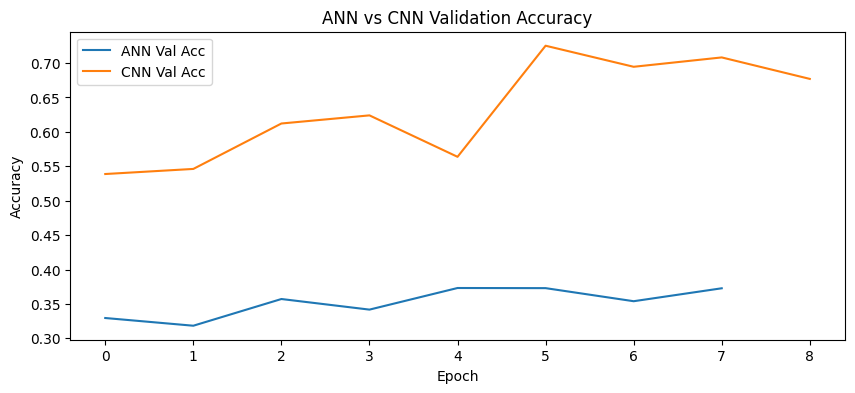

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [ ]:
data_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.1),

    layers.RandomZoom(0.1)

])


aug_cnn_model = models.Sequential([


    data_augmentation,


    layers.Conv2D(
        32,
        3,
        activation='relu',
        input_shape=(32,32,3)
    ),


    layers.MaxPooling2D(),


    layers.Conv2D(
        64,
        3,
        activation='relu'
    ),


    layers.MaxPooling2D(),


    layers.Flatten(),


    layers.Dense(
        128,
        activation='relu'
    ),


    layers.Dropout(0.4),


    layers.Dense(
        10,
        activation='softmax'
    )

])


aug_cnn_model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']

)


aug_history = aug_cnn_model.fit(

    x_train_norm,

    y_train,

    epochs=20,

    validation_split=0.1,

    batch_size=64,

    callbacks=[early_stop]

)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 75s 102ms/step - accuracy: 0.3603 - loss: 1.7523 - val_accuracy: 0.4456 - val_loss: 1.5242
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 71s 101ms/step - accuracy: 0.4540 - loss: 1.5177 - val_accuracy: 0.5020 - val_loss: 1.3537
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 99ms/step - accuracy: 0.4912 - loss: 1.4166 - val_accuracy: 0.5530 - val_loss: 1.2413


# 📊 Final Comparison Table

In [ ]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.3728
1,CNN,0.7085


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**